# Circuits for Lesson 6 of the Tutorial (Part 1)

The 21 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 6 of the Tutorial (Part 1)*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# !pip install symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.16'

## 1. Bo2's Example 4.15

In this problem, we run a transient (TR) analysis and describe a capacitor for the first time. The source's value is t itself; find the voltage across the capacitor, and then its value at t = 2 s, which is 1 V. The Solve card is how version 9 does the calculator's `|t=2`. Naming t as an unknown is what makes the second equation bite.

![The circuit of Bo2's Example 4.15](https://learn.symbulator.com/assets/circuit/bo2e0415.jpg)

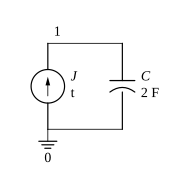

In [3]:
c1 = '''
j,0,1,t
c,1,0,2,0
'''
draw(c1)

In [4]:
r1 = tr(c1)
r1

Result(domain='tr')
  i_c = t
  i_j = t
  v_1 = t**2/4

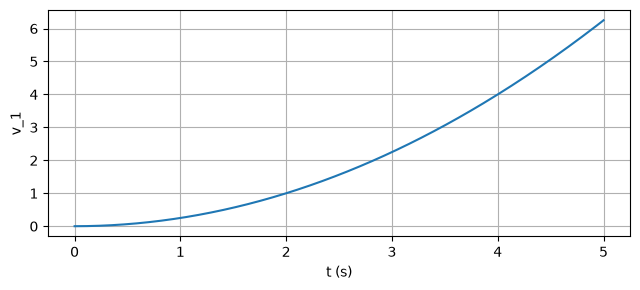

In [5]:
ts, ys = time_samples(c1, 'v_1', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_1'); plt.grid(True); plt.tight_layout()

In [6]:
solve(r1, ['x = vc', 't = 2'], ['x', 't'])

[{'x': 1, 't': 2}]

## 2. Bo2's Example 5.1 (DC, for the initial condition)

The DC half of a two-interval problem: for t < 0 the circuit has long settled, so a DC solve gives the capacitor's voltage — the initial condition the next entry needs.

![The circuit of Bo2's Example 5.1 (DC, for the initial condition)](https://learn.symbulator.com/assets/practice/bo2s-example-5-1-2.jpg)

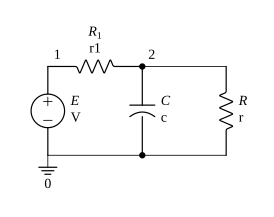

In [7]:
c2 = '''
e,1,0,V
r1,1,2,r1
c,2,0,c
r,2,0,r
'''
draw(c2)

In [8]:
r2 = dc(c2)
r2

Result(domain='dc')
  i_c = 0
  i_e = -V/(r + r1)
  i_r = V/(r + r1)
  i_r1 = V/(r + r1)
  p_c = 0
  p_e = -V**2/(r + r1)
  p_r = V**2*r/(r + r1)**2
  p_r1 = V**2*r1/(r + r1)**2
  r_e = r + r1
  v_1 = V
  v_2 = V*r/(r + r1)
  v_c = V*r/(r + r1)
  v_e = V
  v_r = V*r/(r + r1)
  v_r1 = V*r1/(r + r1)

## 3. Bo2's Example 5.1 (TR)

The TR half: the capacitor carries the initial condition found in DC, and vc decays as e^(-t/(c*r)) times r*v/(r+r1).

![The circuit of Bo2's Example 5.1 (TR)](https://learn.symbulator.com/assets/practice/bo2s-example-5-1-2.jpg)

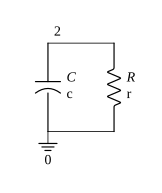

In [9]:
c3 = '''
c,2,0,c,r*v/(r+r1)
r,2,0,r
'''
draw(c3)

In [10]:
r3 = tr(c3)
r3

Result(domain='tr')
  i_c = -v*exp(-t/(c*r))/(r + r1)
  i_r = v*exp(-t/(c*r))/(r + r1)
  v_2 = r*v*exp(-t/(c*r))/(r + r1)

## 4. Bo2's Drill Exercise 5.1 (DC)

First interval, t < 0: solve in DC for the capacitor's voltage. It is 6 V — the initial condition vc0 of the next entry.

![The circuit of Bo2's Drill Exercise 5.1 (DC)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-1-3.jpg)

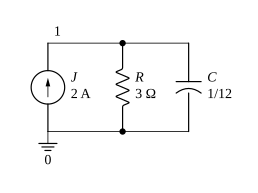

In [11]:
c4 = '''
j,0,1,2
r,1,0,3
c,1,0,1/12
'''
draw(c4)

In [12]:
r4 = dc(c4)
r4

Result(domain='dc')
  i_c = 0
  i_j = 2
  i_r = 2
  p_c = 0
  p_j = -12
  p_r = 12
  r_j = 3
  v_1 = 6
  v_c = 6
  v_j = -6
  v_r = 6

## 5. Bo2's Drill Exercise 5.1 (TR)

Second interval: the source at zero and vc0 as the initial condition, given its value in Define. Find vc and ic: 6e^(-4t) and -2e^(-4t).

![The circuit of Bo2's Drill Exercise 5.1 (TR)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-1-3.jpg)

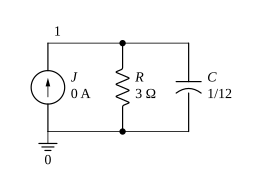

In [13]:
c5 = '''
j,0,1,0
r,1,0,3
c,1,0,1/12,vc0
'''
draw(c5)

In [14]:
r5 = tr(c5, conditions=['vc0=6'])
r5

Result(domain='tr')
  i_c = -2*exp(-4*t)
  i_j = 0
  i_r = 2*exp(-4*t)
  v_1 = 6*exp(-4*t)

## 6. Bo2's p224 5.2 (DC)

First interval in DC: find vc, ic and v2. The capacitor sits at 8 V.

![The circuit of Bo2's p224 5.2 (DC)](https://learn.symbulator.com/assets/practice/bo2s-p224-5-2-4.jpg)

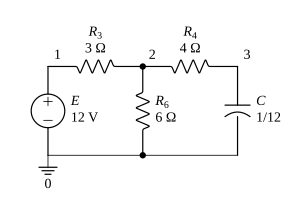

In [15]:
c6 = '''
e,1,0,12
r3,1,2,3
r6,2,0,6
r4,2,3,4
c,3,0,1/12
'''
draw(c6)

In [16]:
r6 = dc(c6)
r6

Result(domain='dc')
  i_c = 0
  i_e = -4/3
  i_r3 = 4/3
  i_r4 = 0
  i_r6 = 4/3
  p_c = 0
  p_e = -16
  p_r3 = 16/3
  p_r4 = 0
  p_r6 = 32/3
  r_e = 9
  v_1 = 12
  v_2 = 8
  v_3 = 8
  v_c = 8
  v_e = 12
  v_r3 = 4
  v_r4 = 0
  v_r6 = 8

## 7. Bo2's p224 5.2 (TR)

Second interval in TR, source at zero, initial condition 8 V: vc, ic and v2 all decay as e^(-2t).

![The circuit of Bo2's p224 5.2 (TR)](https://learn.symbulator.com/assets/practice/bo2s-p224-5-2-4.jpg)

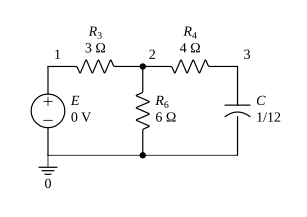

In [17]:
c7 = '''
e,1,0,0
r3,1,2,3
r6,2,0,6
r4,2,3,4
c,3,0,1/12,8
'''
draw(c7)

In [18]:
r7 = tr(c7)
r7

Result(domain='tr')
  i_c = -4*exp(-2*t)/3
  i_e = 8*exp(-2*t)/9
  i_r3 = -8*exp(-2*t)/9
  i_r4 = -4*exp(-2*t)/3
  i_r6 = 4*exp(-2*t)/9
  v_1 = 0
  v_2 = 8*exp(-2*t)/3
  v_3 = 8*exp(-2*t)

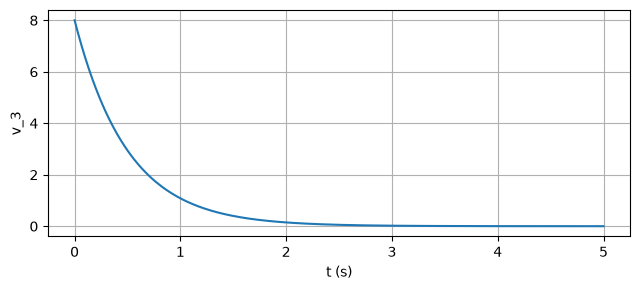

In [19]:
ts, ys = time_samples(c7, 'v_3', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_3'); plt.grid(True); plt.tight_layout()

## 8. Bo2's Drill Exercise 5.2 (DC)

First interval in DC: find vc, ic and v1. The capacitor sits at 6 V.

![The circuit of Bo2's Drill Exercise 5.2 (DC)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-2-5.jpg)

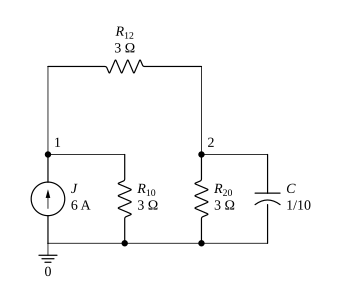

In [20]:
c8 = '''
j,0,1,6
r10,1,0,3
r12,1,2,3
r20,2,0,3
c,2,0,1/10
'''
draw(c8)

In [21]:
r8 = dc(c8)
r8

Result(domain='dc')
  i_c = 0
  i_j = 6
  i_r10 = 4
  i_r12 = 2
  i_r20 = 2
  p_c = 0
  p_j = -72
  p_r10 = 48
  p_r12 = 12
  p_r20 = 12
  r_j = 2
  v_1 = 12
  v_2 = 6
  v_c = 6
  v_j = -12
  v_r10 = 12
  v_r12 = 6
  v_r20 = 6

## 9. Bo2's Drill Exercise 5.2 (TR)

Second interval in TR, the source no longer in the circuit: vc, ic and v1 decay as e^(-5t).

![The circuit of Bo2's Drill Exercise 5.2 (TR)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-2-5.jpg)

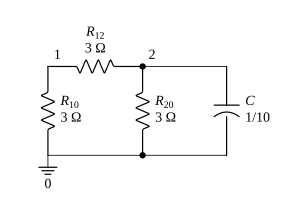

In [22]:
c9 = '''
r10,1,0,3
r12,1,2,3
r20,2,0,3
c,2,0,1/10,6
'''
draw(c9)

In [23]:
r9 = tr(c9)
r9

Result(domain='tr')
  i_c = -3*exp(-5*t)
  i_r10 = exp(-5*t)
  i_r12 = -exp(-5*t)
  i_r20 = 2*exp(-5*t)
  v_1 = 3*exp(-5*t)
  v_2 = 6*exp(-5*t)

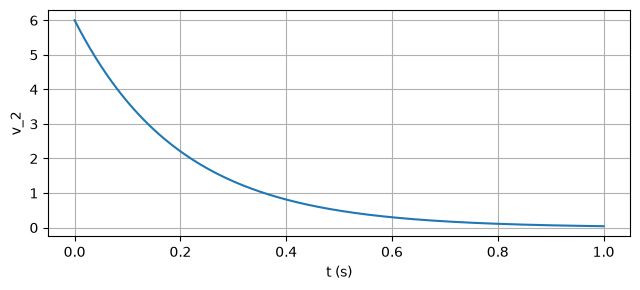

In [24]:
ts, ys = time_samples(c9, 'v_2', 1, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_2'); plt.grid(True); plt.tight_layout()

## 10. Bo2's Figure 5.10a

In this problem, we describe an inductor (the l element) for the first time. Given iL(0) = il0, find vL(t), iL(t) and vR(t), symbolically.

![The circuit of Bo2's Figure 5.10a](https://learn.symbulator.com/assets/practice/bo2s-figure-5-10a-7.jpg)

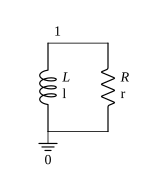

In [25]:
c10 = '''
l,1,0,l,il0
r,1,0,r
'''
draw(c10)

In [26]:
r10 = tr(c10)
r10

Result(domain='tr')
  i_l = il0*exp(-r*t/l)
  i_r = -il0*exp(-r*t/l)
  v_1 = -il0*r*exp(-r*t/l)

## 11. Bo2's Example 5.3 (DC)

First interval of the RL problem, in DC: find il, the inductor's initial condition — v/r1.

![The circuit of Bo2's Example 5.3 (DC)](https://learn.symbulator.com/assets/practice/bo2s-example-5-3-8.jpg)

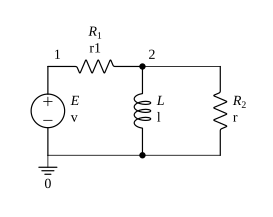

In [27]:
c11 = '''
e,1,0,v
r1,1,2,r1
l,2,0,l
r2,2,0,r
'''
draw(c11)

In [28]:
r11 = dc(c11)
r11

Result(domain='dc')
  i_e = -v/r1
  i_l = v/r1
  i_r1 = v/r1
  i_r2 = 0
  p_e = -v**2/r1
  p_l = 0
  p_r1 = v**2/r1
  p_r2 = 0
  r_e = r1
  v_1 = v
  v_2 = 0
  v_e = v
  v_l = 0
  v_r1 = v
  v_r2 = 0

## 12. Bo2's Example 5.3 (TR)

Second interval in TR: il decays as e^(-r*t/l) times v/r1.

![The circuit of Bo2's Example 5.3 (TR)](https://learn.symbulator.com/assets/practice/bo2s-example-5-3-8.jpg)

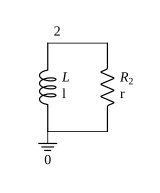

In [29]:
c12 = '''
l,2,0,l,v/r1
r2,2,0,r
'''
draw(c12)

In [30]:
r12 = tr(c12)
r12

Result(domain='tr')
  i_l = v*exp(-r*t/l)/r1
  i_r2 = -v*exp(-r*t/l)/r1
  v_2 = -r*v*exp(-r*t/l)/r1

## 13. Bo2's Drill Exercise 5.3 (DC)

Find iL(t), vL(t) and i(t) for all t; this first interval in DC gives the initial condition, 2 A. The chapter asks for ir1 here; this circuit's resistors are r4 and r12, and the 2 A it prints is ir4.

![The circuit of Bo2's Drill Exercise 5.3 (DC)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-3-9.jpg)

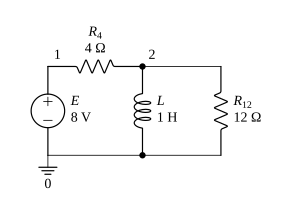

In [31]:
c13 = '''
e,1,0,8
r4,1,2,4
l,2,0,1
r12,2,0,12
'''
draw(c13)

In [32]:
r13 = dc(c13)
r13

Result(domain='dc')
  i_e = -2
  i_l = 2
  i_r12 = 0
  i_r4 = 2
  p_e = -16
  p_l = 0
  p_r12 = 0
  p_r4 = 16
  r_e = 4
  v_1 = 8
  v_2 = 0
  v_e = 8
  v_l = 0
  v_r12 = 0
  v_r4 = 8

## 14. Bo2's Drill Exercise 5.3 (TR)

Second interval in TR with the source at zero: il, vl and ir4 all decay as e^(-3t).

![The circuit of Bo2's Drill Exercise 5.3 (TR)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-3-9.jpg)

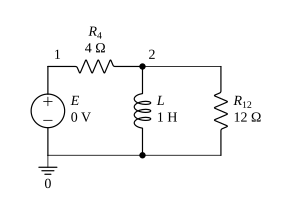

In [33]:
c14 = '''
e,1,0,0
r4,1,2,4
l,2,0,1,2
r12,2,0,12
'''
draw(c14)

In [34]:
r14 = tr(c14)
r14

Result(domain='tr')
  i_e = -3*exp(-3*t)/2
  i_l = 2*exp(-3*t)
  i_r12 = -exp(-3*t)/2
  i_r4 = 3*exp(-3*t)/2
  v_1 = 0
  v_2 = -6*exp(-3*t)

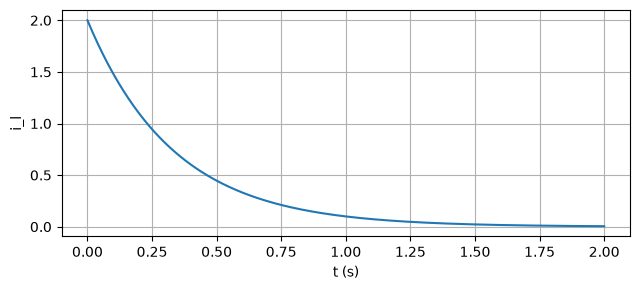

In [35]:
ts, ys = time_samples(c14, 'i_l', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 15. Bo2's p230 (Dependent source)

A transient with a dependent source in it: given iL(0) = 5 A, find iL(t). It decays as 5e^(-r*t/(3*l)).

![The circuit of Bo2's p230 (Dependent source)](https://learn.symbulator.com/assets/practice/bo2s-p230-dependent-source-10.jpg)

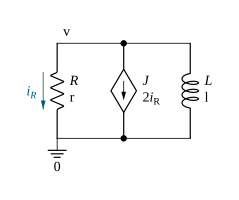

In [36]:
c15 = '''
r,v,0,r
j,v,0,2*ir
l,v,0,l,5
'''
draw(c15)

In [37]:
r15 = tr(c15)
r15

Result(domain='tr')
  i_j = -10*exp(-r*t/(3*l))/3
  i_l = 5*exp(-r*t/(3*l))
  i_r = -5*exp(-r*t/(3*l))/3
  v_v = -5*r*exp(-r*t/(3*l))/3

## 16. Bo2's Drill Exercise 5.4 (Dependent source, DC)

First interval in DC: find il and vl. The initial condition is 2 A.

![The circuit of Bo2's Drill Exercise 5.4 (Dependent source, DC)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-4-dependent-source-11.jpg)

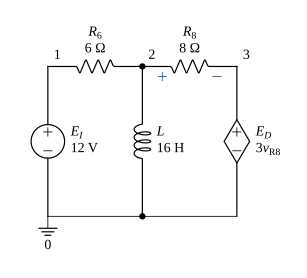

In [38]:
c16 = '''
ei,1,0,12
r6,1,2,6
l,2,0,16
r8,2,3,8
ed,3,0,3*vr8
'''
draw(c16)

In [39]:
r16 = dc(c16)
r16

Result(domain='dc')
  i_ed = 0
  i_ei = -2
  i_l = 2
  i_r6 = 2
  i_r8 = 0
  p_ed = 0
  p_ei = -24
  p_l = 0
  p_r6 = 24
  p_r8 = 0
  r_ei = 6
  v_1 = 12
  v_2 = 0
  v_3 = 0
  v_ed = 0
  v_ei = 12
  v_l = 0
  v_r6 = 12
  v_r8 = 0

## 17. Bo2's Drill Exercise 5.4 (Dependent source, TR)

Second interval in TR: il and vl come back 2e^(-2t) and -64e^(-2t).

![The circuit of Bo2's Drill Exercise 5.4 (Dependent source, TR)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-4-dependent-source-11.jpg)

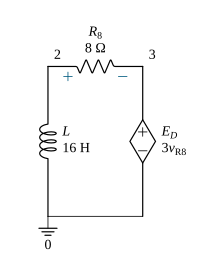

In [40]:
c17 = '''
l,2,0,16,2
r8,2,3,8
ed,3,0,3*vr8
'''
draw(c17)

In [41]:
r17 = tr(c17)
r17

Result(domain='tr')
  i_ed = -2*exp(-2*t)
  i_l = 2*exp(-2*t)
  i_r8 = -2*exp(-2*t)
  v_2 = -64*exp(-2*t)
  v_3 = -48*exp(-2*t)

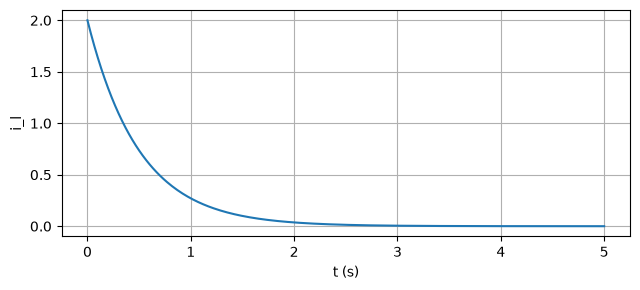

In [42]:
ts, ys = time_samples(c17, 'i_l', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 18. Bo2's Example 5.5 (Op Amp, DC)

An op amp joins the transient problems. First interval in DC: find vc, ic and vo — the capacitor sits at 10 V.

![The circuit of Bo2's Example 5.5 (Op Amp, DC)](https://learn.symbulator.com/assets/practice/bo2s-example-5-5-op-amp-12.jpg)

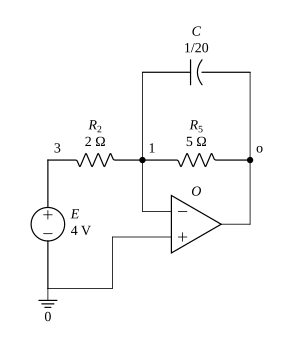

In [43]:
c18 = '''
e,3,0,4
r2,3,1,2
r5,1,o,5
c,1,o,1/20
o,0,1,o
'''
draw(c18)

In [44]:
r18 = dc(c18)
r18

Result(domain='dc')
  i_c = 0
  i_e = -2
  i_o = -2
  i_r2 = 2
  i_r5 = 2
  p_c = 0
  p_e = -8
  p_o = -20
  p_r2 = 8
  p_r5 = 20
  r_e = 2
  v_1 = 0
  v_3 = 4
  v_c = 10
  v_e = 4
  v_o = -10
  v_r2 = 4
  v_r5 = 10

## 19. Bo2's Example 5.5 (Op Amp, TR)

Second interval in TR: vc, ic and vo all decay as e^(-4t).

![The circuit of Bo2's Example 5.5 (Op Amp, TR)](https://learn.symbulator.com/assets/practice/bo2s-example-5-5-op-amp-12.jpg)

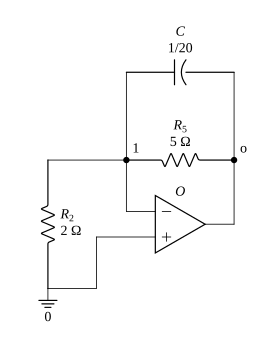

In [45]:
c19 = '''
r2,0,1,2
r5,1,o,5
c,1,o,1/20,10
o,0,1,o
'''
draw(c19)

In [46]:
r19 = tr(c19)
r19

Result(domain='tr')
  i_c = -2*exp(-4*t)
  i_o = 0
  i_r2 = 0
  i_r5 = 2*exp(-4*t)
  v_1 = 0
  v_o = -10*exp(-4*t)

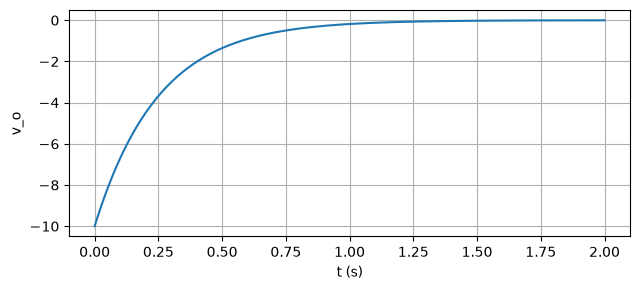

In [47]:
ts, ys = time_samples(c19, 'v_o', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()

## 20. Bo2's Drill Exercise 5.5 (Op Amp, DC)

First interval in DC: find vc, ic and vo — 10 V, 0 and 14 V.

![The circuit of Bo2's Drill Exercise 5.5 (Op Amp, DC)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-5-op-amp-13.jpg)

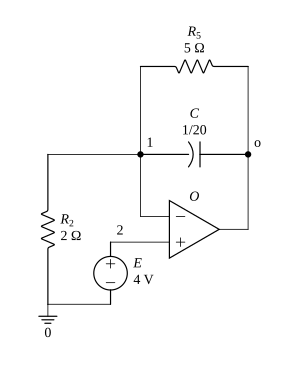

In [48]:
c20 = '''
e,2,0,4
o,2,1,o
c,o,1,1/20
r5,o,1,5
r2,1,0,2
'''
draw(c20)

In [49]:
r20 = dc(c20)
r20

Result(domain='dc')
  i_c = 0
  i_e = 0
  i_o = 2
  i_r2 = 2
  i_r5 = 2
  p_c = 0
  p_e = 0
  p_o = -28
  p_r2 = 8
  p_r5 = 20
  r_e = oo
  v_1 = 4
  v_2 = 4
  v_c = 10
  v_e = 4
  v_o = 14
  v_r2 = 4
  v_r5 = 10

## 21. Bo2's Drill Exercise 5.5 (Op Amp, TR)

Second interval in TR: 10e^(-4t), -2e^(-4t) and 10e^(-4t).

![The circuit of Bo2's Drill Exercise 5.5 (Op Amp, TR)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-5-op-amp-13.jpg)

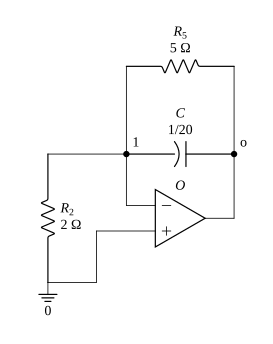

In [50]:
c21 = '''
o,0,1,o
c,o,1,1/20,10
r5,o,1,5
r2,1,0,2
'''
draw(c21)

In [51]:
r21 = tr(c21)
r21

Result(domain='tr')
  i_c = -2*exp(-4*t)
  i_o = 0
  i_r2 = 0
  i_r5 = 2*exp(-4*t)
  v_1 = 0
  v_o = 10*exp(-4*t)

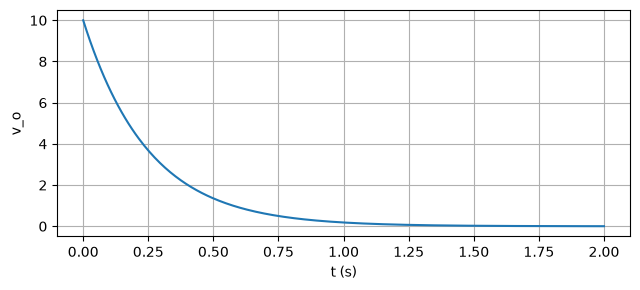

In [52]:
ts, ys = time_samples(c21, 'v_o', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()